## RiverCast: Forecasting Marikina River Level using Principal Component Analysis and Transformer

### Import Dataset and Libraries

In [204]:
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import copy
import math
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # configure GPU utilization

In [205]:
df = pd.read_csv('riverlevel.csv')

### Prepare the Dataset

To make sure that our data types are suited for learning, the researchers converted 'Month', 'Day', and 'Year' columns to timestamps; converted all numerical values into double precision floating numbers; filled in NULL values; and resampled the data to 24-hour intervals.

In [206]:
# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)

# convert year, month, day, and hour columns into timestamp
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

# assign timestamps as the data frame index
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

# select the parameters
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']] 
df = df.astype(np.float64)  # convert parameters into a double precision floating number

# fill in missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('24H').max()  # resample dataset using the max value for each 24-hours

df.head(10)  # display data frame

### Clean Dataset

The researchers reduced the outliers in the dataset using moving average smoothing. Note the we only reduced the outliers but not completely remove them to enable the model learn about flooding incidents.

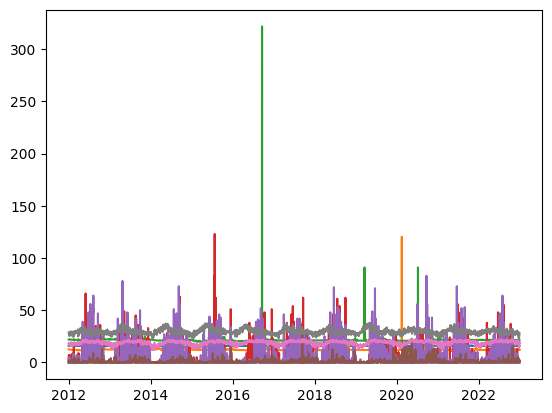

In [211]:
# visualize the current dataset
plt.plot(df)
plt.show()

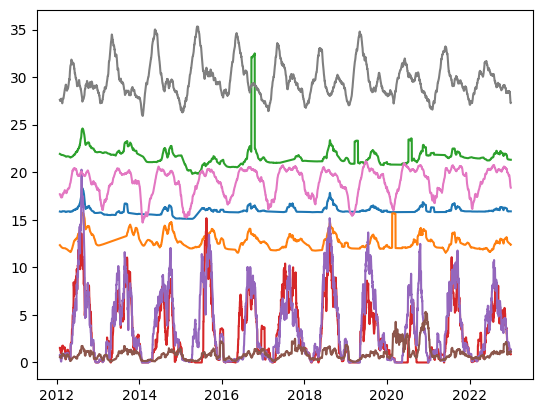

In [212]:
df = df.rolling(30).mean().dropna()  # perform moving average smoothing

# visualize dataset with reduced outliers
plt.plot(df)
plt.show()

### Principal Component Analysis

Principal Component Analysis (PCA) is a dimensionality reduction technique to transform high-dimensional data into a lower-dimensional form while retaining as much of the original information as possible. In the context of forecasting, the researchers utilized PCA to select only the relevant variables at each time step. 

In performing PCA, the researchers first calculate the covariance matrix of the data. The covariance matrix quantifies the relationships and variances between parameters. The next step is to find the eigenvalues and eigenvectors of the covariance matrix. Eigenvalues represent the variance of the data along the corresponding eigenvector, and the eigenvectors represent the directions in feature space that maximize the variance. Then, the eigenvectors are sorted based on their corresponding eigenvalues. Lastly, the researchers selected two principal components and projected the original data to these components. 

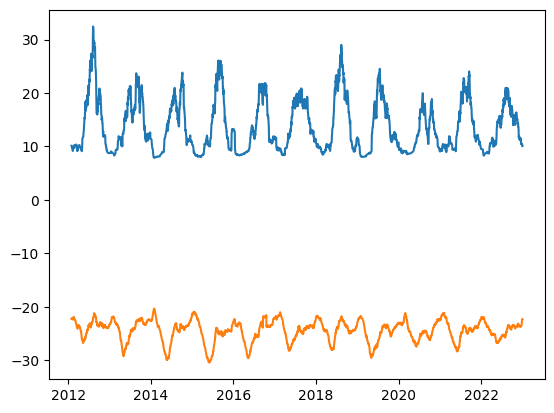

In [213]:
# compute covariance matrix
cov_matrix = np.cov(df, ddof=0, rowvar=False)

# compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
order_of_importance = np.argsort(eigenvalues)[::-1] 

# sort eigenvalues and eigenvectors
sorted_eigenvalues = eigenvalues[order_of_importance].real
sorted_eigenvectors = eigenvectors[:,order_of_importance].real

k = 2  # number of features to preserve
std_data = np.matmul(df, sorted_eigenvectors[:, :k]) # transform the original data

plt.plot(std_data)
plt.show()

### Normalize Dataset

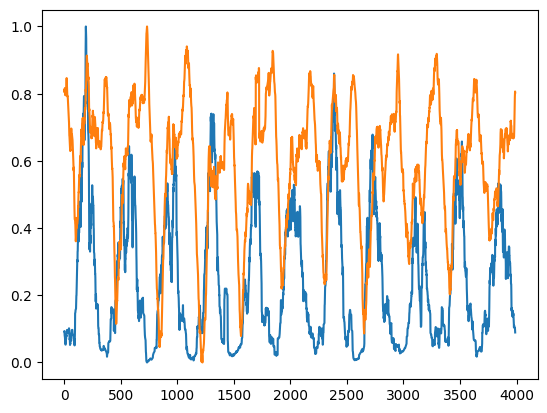

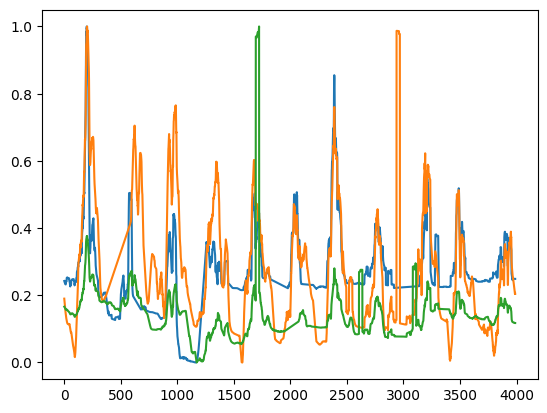

In [214]:
input_scaler = MinMaxScaler()
label_scaler = MinMaxScaler()

inputs = input_scaler.fit_transform(std_data)

plt.plot(inputs)
plt.show()

river_df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2']]
labels = label_scaler.fit_transform(river_df)

plt.plot(labels)
plt.show()

### Prepare Dataset Batches

Time-series data from January 2012 to December 2019 will serve as the training dataset while the data from January 2020 to December 2022 will serve as the test dataset. Moreover take note that the input data are the reduced data from Principal Component Analysis.

In [215]:
train_in = inputs[:2922]
train_out = labels[:2922]

print(train_in.shape)
print(train_out.shape)

test_in = inputs[-1095:]
test_out = labels[-1095:]

print(test_in.shape)
print(test_out.shape)

(2922, 2)
(2922, 3)
(1095, 2)
(1095, 3)


In [216]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, outputs, seq_len):
        self.inputs = inputs
        self.outputs = outputs
        self.seq_len = seq_len
        
    def __getitem__(self, index):
        in_start = index
        in_end = in_start + self.seq_len
        out_start = index + int(self.seq_len / 2)
        out_end = out_start + self.seq_len
        
        inputs = self.inputs[in_start:in_end]
        labels = self.outputs[out_start:out_end]
        
        return inputs, labels
    
    def __len__(self):
        return len(self.inputs) - (int(self.seq_len / 2) * 3) + 1

In [217]:
BATCH_SIZE = 64
SEQ_LEN = 730

train_dataset = TimeSeriesDataset(train_in, train_out, seq_len=SEQ_LEN)
test_dataset = TimeSeriesDataset(test_in, test_out, seq_len=SEQ_LEN)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(len(train_dataloader))
print(len(test_dataloader))

29
1


In [218]:
PRED_SIZE = 3
D_MODEL = 2
NUM_HEADS = 1
NUM_LAYERS = 2
D_FF = 2048
MAX_SEQ_LEN = 730 
DROPOUT = 0.10

#### Attention Mechanism

In the context of forecasting, a multi-head attention mechanism allows the model to weigh the importance of different time points in a time period thus allowing the model to capture the relationship between past events and current events. The attention scores are calculated by comparing the input sequence (after linear projection) against itself or against a query vector. In addition, the diagonal mask ensure that the attention mechanism only compares past events to future events but not vice versa to avoid over fitting.

In [219]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
            
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        
        return attn_probs, output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        attn_scores, attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return attn_scores, output

#### Positional Encoding

Unlike human brains, neural networks are not aware of order. It cannot distinguish past values from future values. That is why, the purpose of positional encoding is to help the model distinguish between different elements in a sequence and understand the sequential order of data.

In [220]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=1024):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### Feed Forward Network

Feed Forward Network is a fundamental type of artificial neural network. In the context of transformer models, the feed forward network aims to learn the relationship between the temporal features and the forecasted values.

In [221]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

#### Decoder Layer

The decoder layer is the combination of masked attention mechanisms and a feed forward network. The primary purpose of the decoder layer is to generate future values in a autoregressive manner, based on the context and extracted features from seasonal trend decomposition and attention mechanism.

In [222]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        attn_scores, attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return attn_scores, x

In [223]:
class Transformer(nn.Module):
    def __init__(self, pred_size, d_model, num_heads, num_layers, d_ff, dropout):
        super(Transformer, self).__init__()
        self.positional_encoding = PositionalEncoding(d_model)
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, pred_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)
        
    def generate_mask(self, tgt):
        seq_length = tgt.size(1)
        tgt_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        return tgt_mask

    def forward(self, tgt):
        mask = self.generate_mask(tgt).to(device)
        tgt_embedded = self.dropout(self.positional_encoding(tgt))

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            attn_scores, dec_output = dec_layer(dec_output, mask)

        output = self.sigmoid(self.fc(dec_output))
        return attn_scores, output

### Train Transformer Module

In [224]:
reducer = Transformer(
    pred_size=PRED_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).float()

reducer.to(device)

device

device(type='cuda', index=0)

In [225]:
reducer.eval()

sample = np.reshape(test_in[:MAX_SEQ_LEN], (1, MAX_SEQ_LEN, D_MODEL))
output = torch.from_numpy(sample).float().to(device)
scores, output = reducer(output)
output = output.detach().cpu().numpy()
scores = scores.detach().cpu().numpy()

print(output.shape)
print(scores.shape)

(1, 730, 3)
(1, 1, 730, 730)


In [226]:
def train_reducer(train_dataloader, val_dataloader, epochs=10, es_value=0.010):
    time_now = time.time()
    train_steps = len(train_dataloader)
    train_epochs = epochs

    # initialize optimizer that will adjust the model's weights and biases during training
    model_optim = torch.optim.Adam(reducer.parameters(), lr=0.001)
    
    # initialize loss function that will determine the error between the actual values and forecasted values
    loss_fn = torch.nn.MSELoss()

    for epoch in range(train_epochs):
        iter_count = 0
        train_loss = []

        reducer.train()
        epoch_time = time.time()
        for i, (inputs, labels) in enumerate(train_dataloader):
            iter_count += 1
            model_optim.zero_grad()  # reset gradients
            
            batch_x = inputs.float().to(device)  # convert values to float and send to GPU
            batch_y = labels.float().to(device)  # convert values to float and send to GPU

            scores, outputs = reducer(batch_x)

            loss = loss_fn(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()  # compute gradients
            model_optim.step()  # update model parameters
            
            if (i + 1) % 10 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time() 

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        
        # evaluate model
        val_loss = []
        reducer.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_dataloader):
                batch_x = inputs.float().to(device)
                batch_y = labels.float()

                scores, outputs = reducer(batch_x)
                outputs = outputs.detach().cpu()

                loss = loss_fn(outputs, batch_y)

                val_loss.append(loss)
        val_loss = np.average(val_loss)
        
        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Validation Loss: {3:.7f}".format(epoch + 1, train_steps, train_loss, val_loss))
        
        # stop training upon reaching the optimal accuracy to avoid over fitting
        if val_loss < es_value:
            break
        
        reducer.train()
        
    torch.save(reducer.state_dict(), 'reducer.pth')  # save model

In [227]:
train_reducer(train_dataloader, test_dataloader, epochs=20, es_value=0.010)

	iters: 10, epoch: 1 | loss: 0.1822998
	speed: 0.9441s/iter; left time: 539.1044s
	iters: 20, epoch: 1 | loss: 0.1442080
	speed: 0.2477s/iter; left time: 138.9598s
Epoch: 1 cost time: 9.60590672492981
Epoch: 1, Steps: 29 | Train Loss: 0.1584977 Validation Loss: 0.1302382
	iters: 10, epoch: 2 | loss: 0.1570399
	speed: 0.4771s/iter; left time: 258.5880s
	iters: 20, epoch: 2 | loss: 0.1218689
	speed: 0.2477s/iter; left time: 131.7765s
Epoch: 2 cost time: 7.052996873855591
Epoch: 2, Steps: 29 | Train Loss: 0.1347253 Validation Loss: 0.1081062
	iters: 10, epoch: 3 | loss: 0.1344820
	speed: 0.4650s/iter; left time: 238.5450s
	iters: 20, epoch: 3 | loss: 0.1024565
	speed: 0.2482s/iter; left time: 124.8446s
Epoch: 3 cost time: 7.014004707336426
Epoch: 3, Steps: 29 | Train Loss: 0.1141733 Validation Loss: 0.0889952
	iters: 10, epoch: 4 | loss: 0.1148577
	speed: 0.4610s/iter; left time: 223.1245s
	iters: 20, epoch: 4 | loss: 0.0859462
	speed: 0.2479s/iter; left time: 117.5044s
Epoch: 4 cost time

### Test Model

In [229]:
reducer.load_state_dict(torch.load('reducer.pth'))

<All keys matched successfully>

In [230]:
reducer.eval()

inputs, labels = [(inputs, labels) for _, (inputs, labels) in enumerate(test_dataloader)][0]

print(inputs.shape)
print(labels.shape)

torch.Size([1, 730, 2])
torch.Size([1, 730, 3])


In [231]:
x_test = inputs.float().to(device)

attn_scores, y_test = reducer(x_test)
y_test = torch.squeeze(y_test, dim=0)
y_test = y_test.detach().cpu().numpy()
y_test = y_test[-365:]
y_test = label_scaler.inverse_transform(y_test)

ground = torch.squeeze(labels, dim=0)
ground = ground.numpy()
ground = ground[-365:]
ground = label_scaler.inverse_transform(ground)

mean_absolute_error(ground, y_test)

0.4999019242371238

#### Visualize Forecast

As you can observe, Transformer with PCA has the least error among the three models. However, its forecast is unrealistic. The researchers observed the following reasons:
 - Reducing the parameters by selecting only the most relevant variable at each time step limits the attention mechanism from capturing rich temporal relationships. This is also evident in the attention score heat map below where the learned weights appears static compared to other models indicating poor temporal features. 
 - PCA utilizes the data variance to select the relevant variables at each time step. Despite being useful in classification problems to eliminate the same classes, that is not the case with forecasting because the model learned the mode instead of the temporal patterns across time steps. If the model forecasts only the most common river level across the year (the mode), the accuracy is undoubtedly lower.

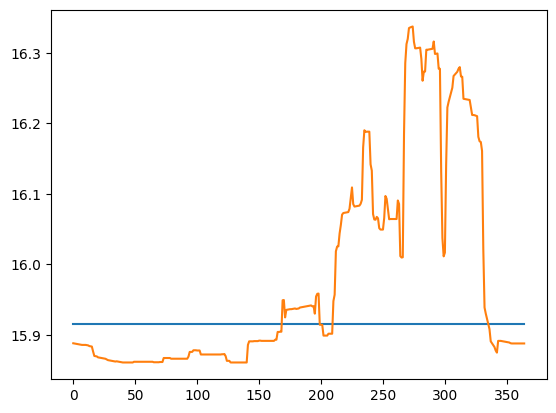

In [232]:
plt.plot(y_test[:, 0])
plt.plot(ground[:, 0])
plt.show()

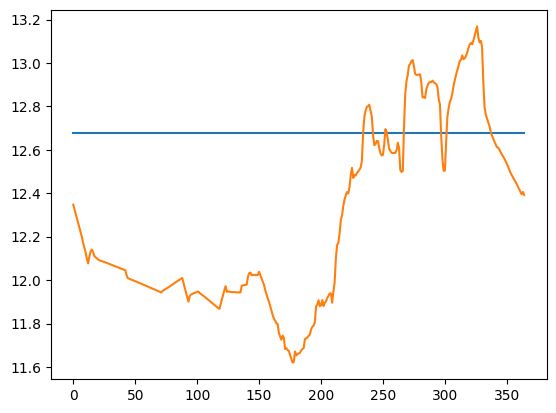

In [233]:
plt.plot(y_test[:, 1])
plt.plot(ground[:, 1])
plt.show()

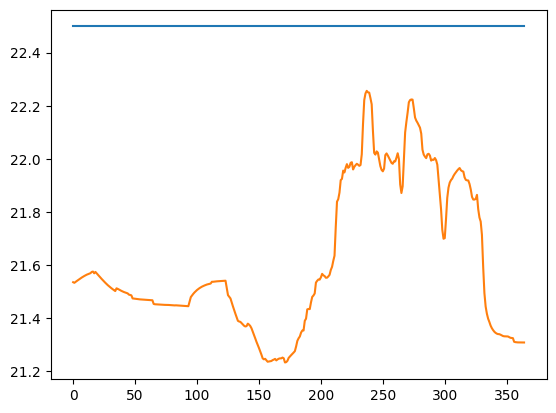

In [234]:
plt.plot(y_test[:, 2])
plt.plot(ground[:, 2])
plt.show()

In [235]:
def plot_attention_head(dates, attention):
    ax = plt.gca()
    ax.matshow(attention)
    ax.set_xticks(range(len(dates)))
    ax.set_yticks(range(len(dates)))

    ax.set_xticklabels(dates, rotation=90)
    ax.set_yticklabels(dates)
    plt.show()

In [236]:
attn_scores =  torch.squeeze(attn_scores, dim=0)
attn_scores = attn_scores.detach().cpu().numpy()
attn_scores.shape

(1, 730, 730)

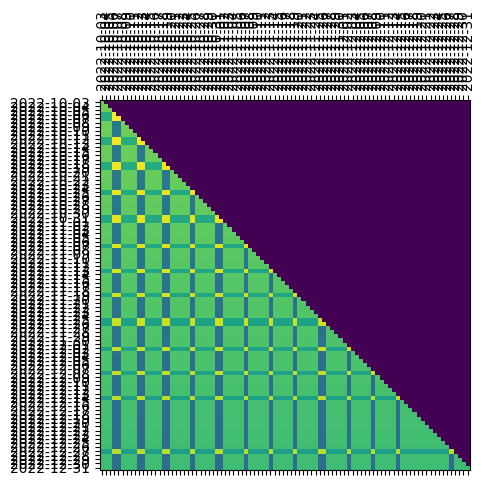

In [237]:
plot_attention_head(df.index[-90:].astype(str), attn_scores[0][-90:, -90:])    